In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import shutil
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.inspection import permutation_importance
from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.color import gray2rgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from PIL import Image

In [2]:
# Load JSON
photos_df = pd.read_json("data/photos.json", lines=True)

In [3]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


Dataset with 200k non null entries.

In [5]:
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

We have 5 distinct labels, related to restaurants, lets see a few photos inside the folder.

In [7]:
selected_photos = ['Km1nuFtDgB-Ln1P4L3U-bg.jpg',
 'cVdE5e9k4bP2kBUlVvMB0A.jpg',
 'j7Qi42Z2UpVr2aR3te-blQ.jpg',
 'bqXKw83_aLw7FJ9F9-lQ2w.jpg',
 'Xd0f5yYNIiDYC2pXgyg63w.jpg',
 'bJbp_NJKIinHB_uh7892oQ.jpg',
 'zxmdEhJqWc-eHQgsXDamPQ.jpg',
 'uaI4Ww9YvniXhanm34tqPA.jpg',
 'Pw-q9AkO4hq3j6P1tcuD2g.jpg']

In [8]:
destination_folder = 'data/random_photos'

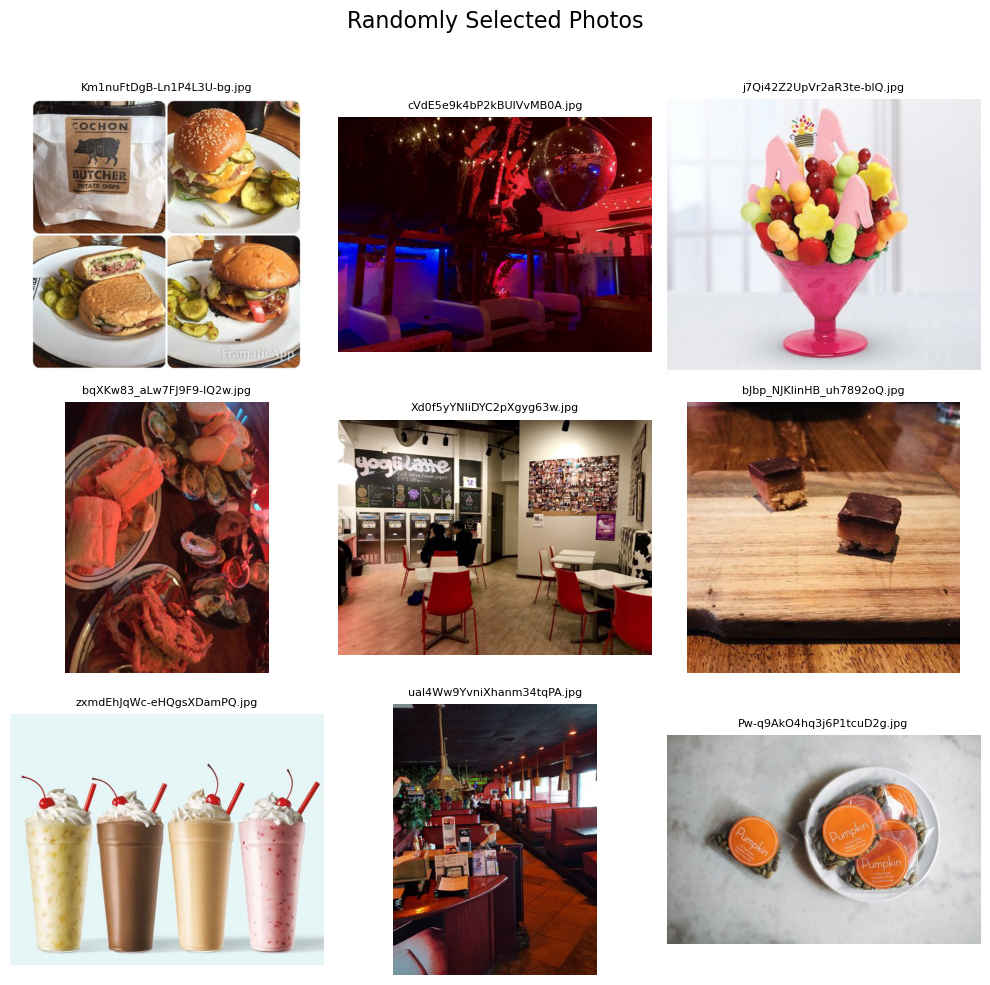

In [9]:
# Display the selected photos in a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Randomly Selected Photos", fontsize=16)

for i, photo in enumerate(selected_photos):
    img_path = os.path.join(destination_folder, photo)
    img = Image.open(img_path)

    row, col = divmod(i, 3)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    axes[row, col].set_title(photo, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

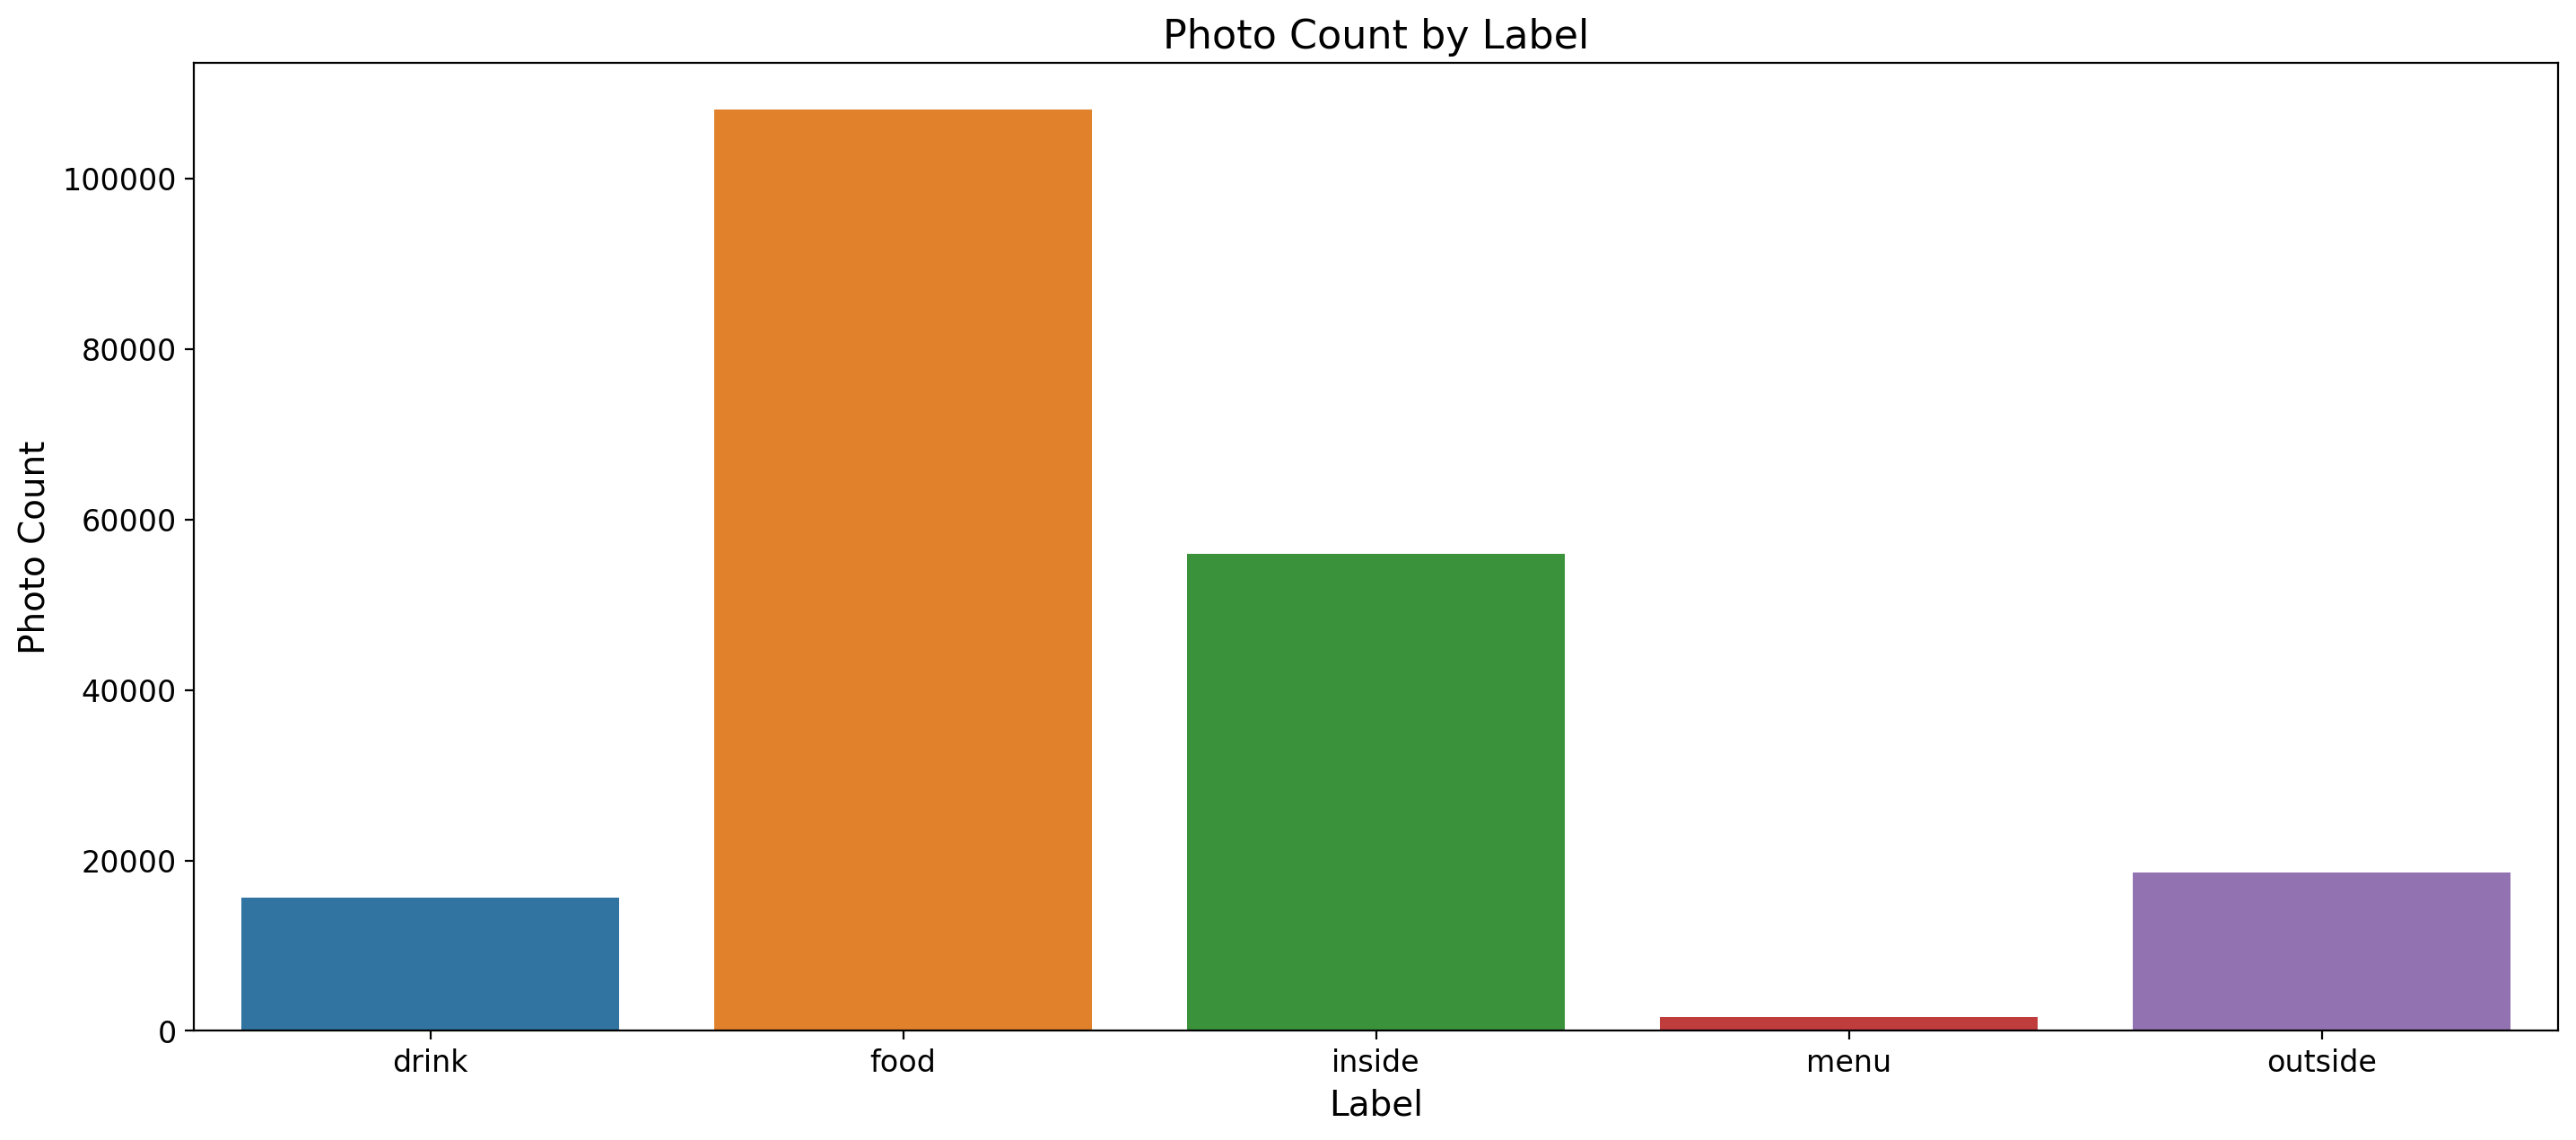

In [10]:
# Plot
plt.figure(figsize=[17, 7],dpi=200)
sns.barplot(data=photos_df.groupby('label')['photo_id'].count().to_frame().reset_index(),x='label', hue='label', y='photo_id')
plt.title("Photo Count by Label", fontsize=16)
plt.xlabel("Label", fontsize=14)
plt.ylabel("Photo Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

There's heavy imbalance to what's a drink, what's a menu, what's outside. Maybe we can use augmentation later to enhance the models.
<b> Let's start preprocessing the model.

## Let's first balance the model and remove some images so that we can run it faster, we will let the 200k for when we start dealing with DNN/CNN

In [13]:
# Here we run the balanced subset.py this will make running knn and svm easier

Balanced subset with 13678 images saved to data/balanced_subset.json.
Copied 13678 images to data/balanced_photos..

In [15]:
balanced_df = pd.read_json("data/balanced_subset.json")

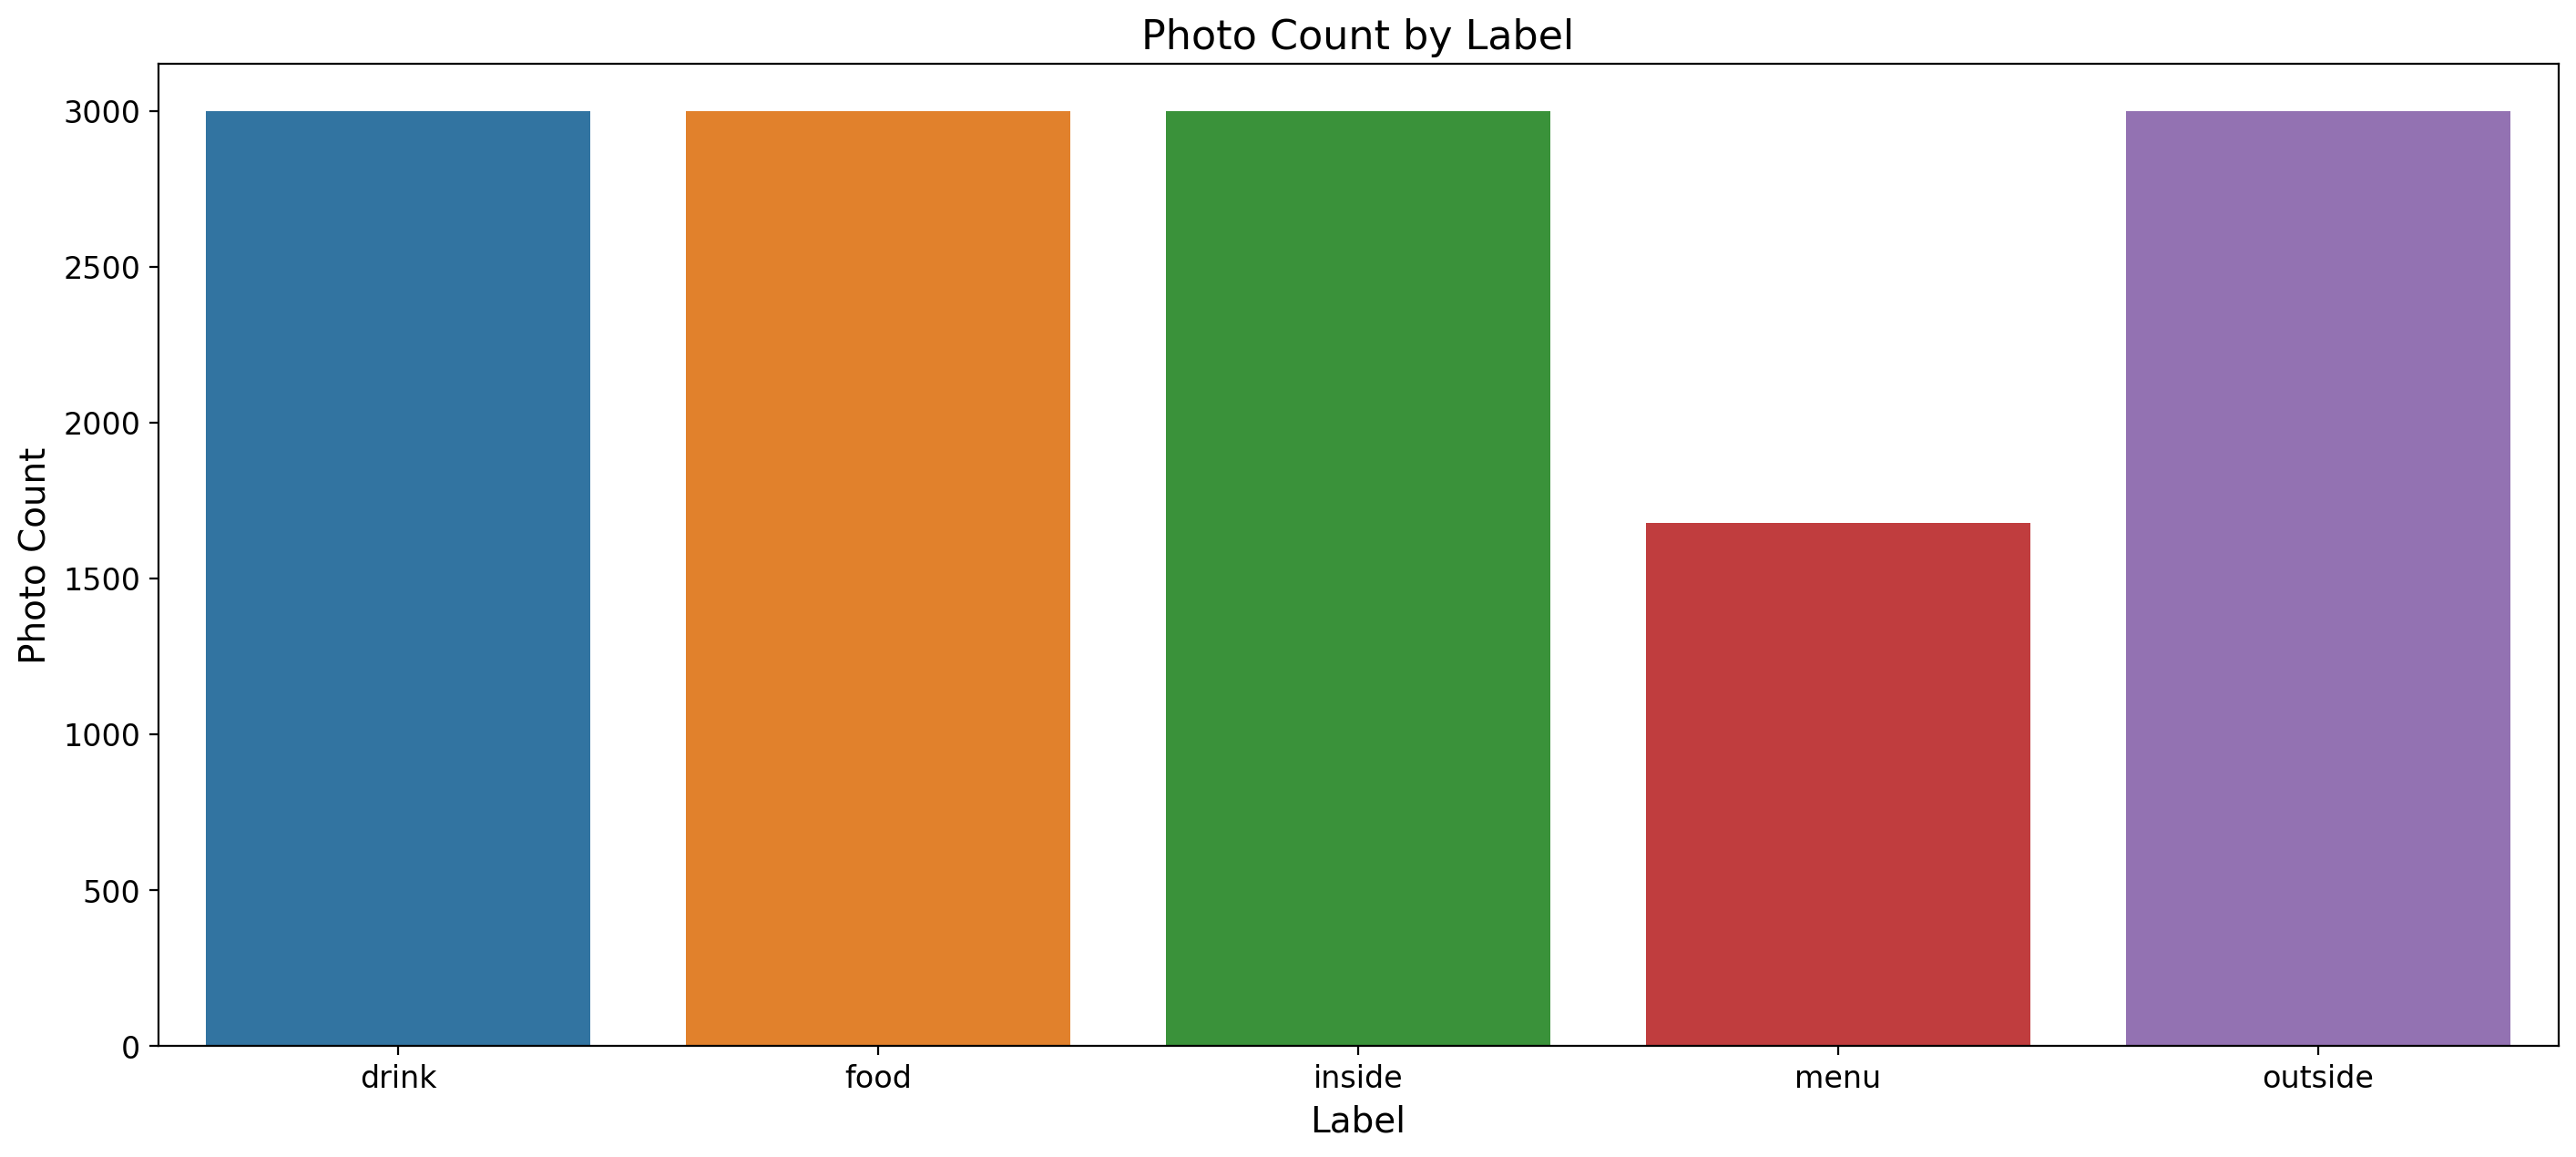

In [16]:
# Plot
plt.figure(figsize=[17, 7],dpi=200)
sns.barplot(data=balanced_df.groupby('label')['photo_id'].count().to_frame().reset_index(),x='label', hue='label', y='photo_id')
plt.title("Photo Count by Label", fontsize=16)
plt.xlabel("Label", fontsize=14)
plt.ylabel("Photo Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

It's already more balanced. With exception of menu that there are too few images.

### Let's load and preprocess the images

In [19]:
balanced_df["photo_id"]

0        FWgsk_oRlBLynLUXUiDuhw
1        srTvwmoOeoug6H95auvdow
2        6j4shXoWQmityfrEHtfdHQ
3        z5nipMhr9lwuM4rizRWFkA
4        ROasyTw9aVg16ML4JYuq2A
                  ...          
13673    tSHKqyWMzjqr8kRz-5c_Ew
13674    PwSdXTPwNYYgkpnv4IiYPw
13675    NZjtffwJ54b-kqjNkAr6OQ
13676    TDLt5joQhP3fNHbWOITRhQ
13677    s79jpLbFPLPIF5kXNCiGzA
Name: photo_id, Length: 13678, dtype: object

In [37]:
def load_and_preprocess_images(photo_ids, img_dir, IMAGE_SIZE = (64, 64)):
    images = []
    missing_ids = []
    for photo_id in photo_ids:
        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            img = Image.open(img_path).resize(IMAGE_SIZE)
            
            images.append(np.array(img))
        except Exception as e:
            missing_ids.append(photo_id)
            print(f"Error loading image {photo_id}: {e}")
    print(f"Missing or problematic images: {len(missing_ids)}")
    return np.array(images), missing_ids

In [20]:
# Load the dataset
X, missing_ids = load_and_preprocess_images(balanced_df["photo_id"], "data/balanced_photos")
y = balanced_df[~balanced_df["photo_id"].isin(missing_ids)]["label"]

Error loading image 2S78q98b_VpBD7vkrDE5-A: cannot identify image file 'C:\\Users\\leand\\GitHub\\AISC-T3-Grp2\\AISC2008 - Computer Vision\\Case Study 1\\Leandro\\data\\balanced_photos\\2S78q98b_VpBD7vkrDE5-A.jpg'
Error loading image rLafN9k3_AF5lZU0cs3LZg: cannot identify image file 'C:\\Users\\leand\\GitHub\\AISC-T3-Grp2\\AISC2008 - Computer Vision\\Case Study 1\\Leandro\\data\\balanced_photos\\rLafN9k3_AF5lZU0cs3LZg.jpg'
Missing or problematic images: 2


In [21]:
X.shape

(13676, 64, 64, 3)

In [22]:
y.shape

(13676,)

In [23]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

### Split into train test and val

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Let's start with the KNN method now.

First let's flatten it to run.

In [28]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [29]:
# Initialize the kNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_flat, y_train)

KNeighborsClassifier()

In [30]:
# Predict on train data
y_train_pred = knn.predict(X_train_flat)
y_train_probs = knn.predict_proba(X_train_flat)

In [31]:
# Same for test
y_test_pred = knn.predict(X_test_flat)
y_test_probs = knn.predict_proba(X_test_flat)

In [32]:
# Same for val
y_val_pred = knn.predict(X_val_flat)
y_val_probs = knn.predict_proba(X_val_flat)

In [33]:
# Evaluate
cm = confusion_matrix(y_train, y_train_pred)
auc = roc_auc_score(y_train, y_train_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Confusion Matrix:
 [[1150  118  151  500  160]
 [ 295 1119   91  532   82]
 [ 145   86  970  690  243]
 [ 132   46   47  863   39]
 [ 109   53  156  413 1383]]
AUC Score: 0.9026580636964324
Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.34      0.39       462
           1       0.60      0.34      0.44       459
           2       0.38      0.22      0.28       422
           3       0.23      0.67      0.35       287
           4       0.60      0.53      0.56       422

    accuracy                           0.40      2052
   macro avg       0.45      0.42      0.40      2052
weighted avg       0.47      0.40      0.41      2052



In [34]:
# Evaluate
cm = confusion_matrix(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Confusion Matrix:
 [[158  48  60 153  43]
 [ 87 158  32 163  19]
 [ 41  25  94 192  70]
 [ 37  14  28 192  16]
 [ 25  18  33 123 223]]
AUC Score: 0.7179392768513743
Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.34      0.39       462
           1       0.60      0.34      0.44       459
           2       0.38      0.22      0.28       422
           3       0.23      0.67      0.35       287
           4       0.60      0.53      0.56       422

    accuracy                           0.40      2052
   macro avg       0.45      0.42      0.40      2052
weighted avg       0.47      0.40      0.41      2052



In [35]:
# Evaluate
cm = confusion_matrix(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_val, y_val_pred))

Confusion Matrix:
 [[173  49  48 137  52]
 [ 84 129  34 152  21]
 [ 36  21 112 206  69]
 [ 42  15  25 170  12]
 [ 30  24  33 114 263]]
AUC Score: 0.7286778963454362
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.38      0.42       459
           1       0.54      0.31      0.39       420
           2       0.44      0.25      0.32       444
           3       0.22      0.64      0.33       264
           4       0.63      0.57      0.60       464

    accuracy                           0.41      2051
   macro avg       0.46      0.43      0.41      2051
weighted avg       0.48      0.41      0.42      2051



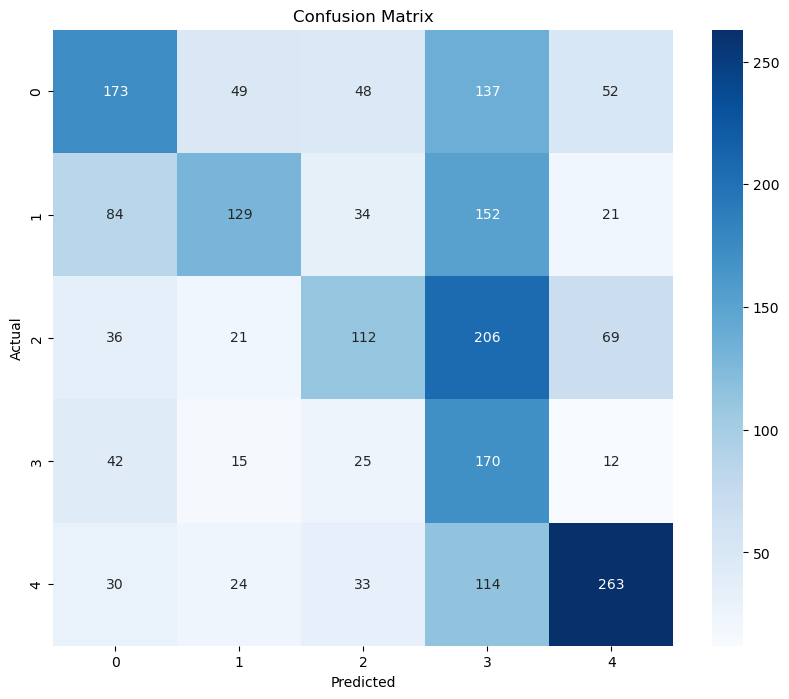

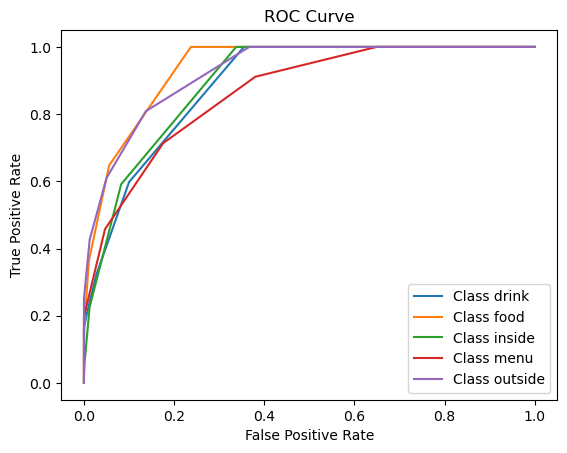

In [36]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC Curve (One-vs-Rest)
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_train == i, y_train_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]}")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

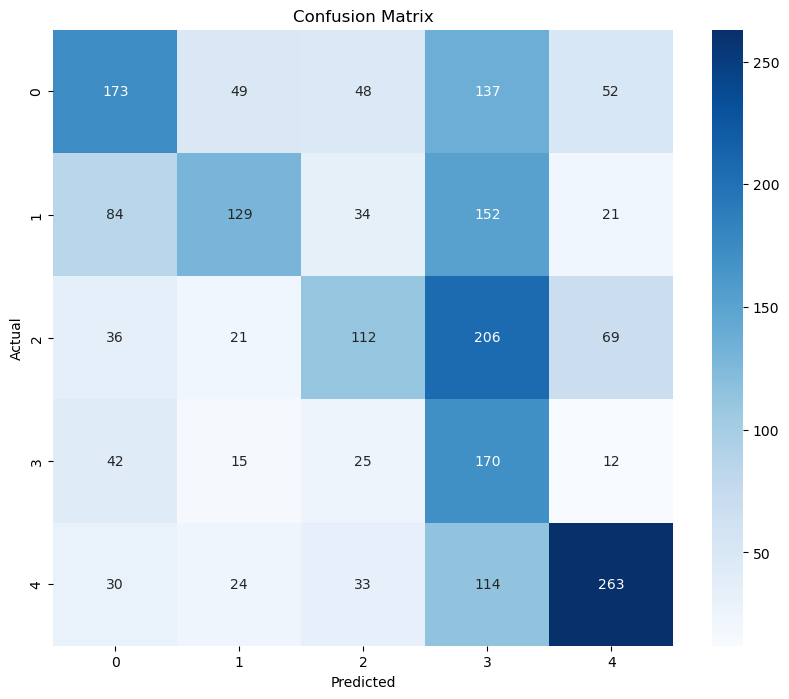

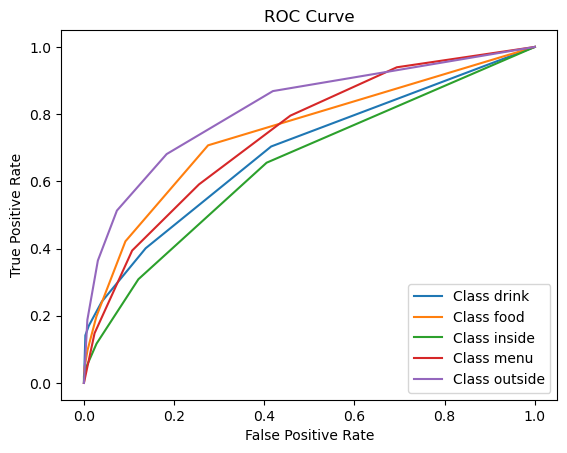

In [37]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC Curve (One-vs-Rest)
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_val == i, y_val_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]}")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

<b> The model looks very poor. In some parts way worse than a coin. Since we are balanced the data let's see if we can get something from global and local interpretability and check if we can improve it somehow. It could be due to the low amount of images but for the sake of the exercise it's fine.

<b>We can also see a lot of overfitting from training to test.

### Global Interpretation

Nearest Neighbors' Labels: [3 4 3 1 0]


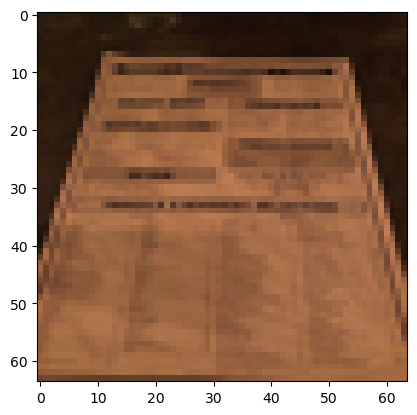

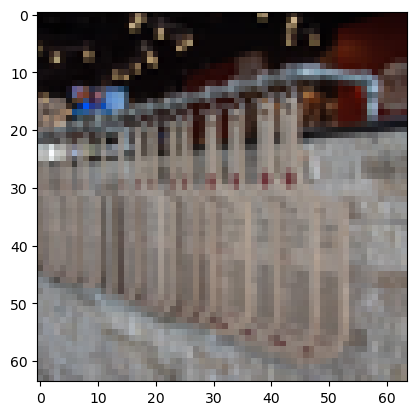

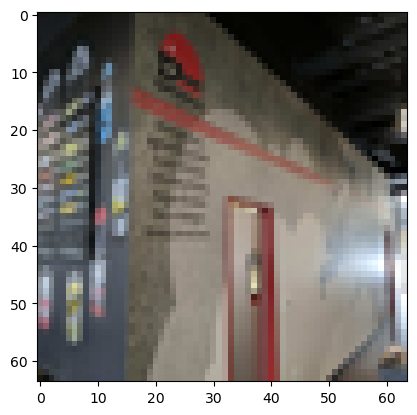

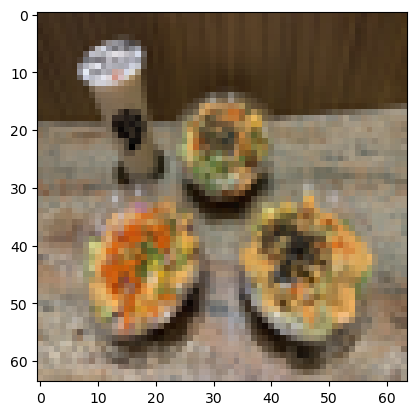

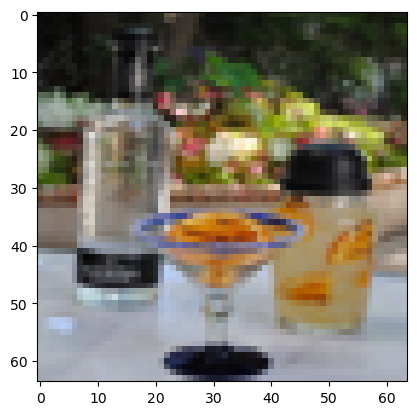

In [57]:
def visualize_nearest_neighbors(knn, instance, X_train, y_train):
    distances, indices = knn.kneighbors(instance.reshape(1, -1))
    print("Nearest Neighbors' Labels:", y_train[indices.flatten()])

    for idx in indices.flatten():
        plt.imshow(X_train[idx].reshape(64, 64, 3).astype("uint8"))
        plt.show()

visualize_nearest_neighbors(knn, X_test_flat[0], X_train, y_train)

In [63]:
def preprocess_image(image):
    """Flatten the image to match the input expected by kNN."""
    return image.reshape(1, -1)

def predict_proba_for_lime(images):
    """Flatten all images for kNN and return predicted probabilities."""
    flattened_images = np.array([img.flatten() for img in images])
    return knn.predict_proba(flattened_images)

  0%|          | 0/1000 [00:00<?, ?it/s]

Top labels explained: [3, 4, 1, 0, 2]


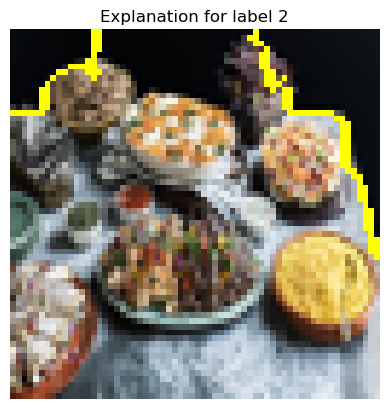

Predicted probabilities: [[0.2 0.2 0.  0.4 0.2]]
True label probability: 0.0


In [65]:
# Example LIME explanation
explainer = lime_image.LimeImageExplainer()

# Explain the first test image
explanation = explainer.explain_instance(
    X_test[0],  # The test image
    predict_proba_for_lime,  # Wrapped prediction function
    labels=[y_test[0]],  # Force LIME to explain the true label
    hide_color=0,
    num_samples=1000
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Visualize the explanation for the true label
temp, mask = explanation.get_image_and_mask(
    label=y_test[0],  # The true label
    positive_only=True,  # Show only positive contributions
    num_features=10,  # Number of features to display
    hide_rest=False  # Show the rest of the image
)

# Convert `temp` to ensure it is in the correct format for visualization
if len(temp.shape) == 2:  # If grayscale, convert to RGB
    temp = gray2rgb(temp)

# Overlay the mask on the image
overlay = mark_boundaries(temp, mask)

# Plot the image with the explanation
plt.imshow(overlay)
plt.title(f"Explanation for label {y_test[0]}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = knn.predict_proba(preprocess_image(X_test[0]))
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, y_test[0]]}")

In [66]:
class_names = label_encoder.classes_
print("Class names:", class_names)

Class names: ['drink' 'food' 'inside' 'menu' 'outside']


<b> the boundaries doesn't match to anything, and it's predicting inside which could be true, but in fact it is food.

  0%|          | 0/1000 [00:00<?, ?it/s]

Top labels explained: [4, 3, 2, 1, 0]


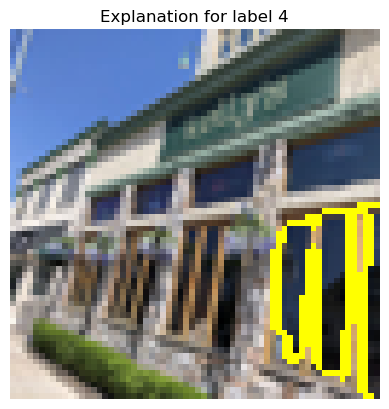

Predicted probabilities: [[0.  0.  0.  0.2 0.8]]
True label probability: 0.8


In [68]:
# Example LIME explanation
explainer = lime_image.LimeImageExplainer()

# Explain the first test image
explanation = explainer.explain_instance(
    X_test[1],  # The test image
    predict_proba_for_lime,  # Wrapped prediction function
    labels=[y_test[1]],  # Force LIME to explain the true label
    hide_color=0,
    num_samples=1000
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Visualize the explanation for the true label
temp, mask = explanation.get_image_and_mask(
    label=y_test[1],  # The true label
    positive_only=True,  # Show only positive contributions
    num_features=10,  # Number of features to display
    hide_rest=False  # Show the rest of the image
)

# Convert `temp` to ensure it is in the correct format for visualization
if len(temp.shape) == 2:  # If grayscale, convert to RGB
    temp = gray2rgb(temp)

# Overlay the mask on the image
overlay = mark_boundaries(temp, mask)

# Plot the image with the explanation
plt.imshow(overlay)
plt.title(f"Explanation for label {y_test[1]}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = knn.predict_proba(preprocess_image(X_test[1]))
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, y_test[1]]}")

<b> We can see that even if the images are very poorly sized, it could see "windows that are outside" to classify it as outside (4)

Let's try to resize the image for our tuning and standardize the data. As it is now it's even hard for us to identify if it's outside or not or if it's food or not.

In [71]:
# Load the dataset
X, missing_ids = load_and_preprocess_images(balanced_df["photo_id"], "data/balanced_photos", IMAGE_SIZE= (100,100))
y = balanced_df[~balanced_df["photo_id"].isin(missing_ids)]["label"]

Error loading image 2S78q98b_VpBD7vkrDE5-A: cannot identify image file 'C:\\Users\\leand\\GitHub\\AISC-T3-Grp2\\AISC2008 - Computer Vision\\Case Study 1\\Leandro\\data\\balanced_photos\\2S78q98b_VpBD7vkrDE5-A.jpg'
Error loading image rLafN9k3_AF5lZU0cs3LZg: cannot identify image file 'C:\\Users\\leand\\GitHub\\AISC-T3-Grp2\\AISC2008 - Computer Vision\\Case Study 1\\Leandro\\data\\balanced_photos\\rLafN9k3_AF5lZU0cs3LZg.jpg'
Missing or problematic images: 2


In [72]:
X.shape

(13676, 100, 100, 3)

In [73]:
y.shape

(13676,)

In [74]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

### Split into train test and val

In [76]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Let's start with the KNN method now.

First let's flatten it to run.

In [79]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [80]:
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_val_flat = scaler.transform(X_val_flat)
X_test_flat = scaler.transform(X_test_flat)

In [81]:
# Initialize the kNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_flat, y_train)

KNeighborsClassifier()

In [82]:
# Predict on train data
y_train_pred = knn.predict(X_train_flat)
y_train_probs = knn.predict_proba(X_train_flat)

In [83]:
# Same for test
y_test_pred = knn.predict(X_test_flat)
y_test_probs = knn.predict_proba(X_test_flat)

In [84]:
# Same for val
y_val_pred = knn.predict(X_val_flat)
y_val_probs = knn.predict_proba(X_val_flat)

In [85]:
# Evaluate
cm = confusion_matrix(y_train, y_train_pred)
auc = roc_auc_score(y_train, y_train_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Confusion Matrix:
 [[1208  122  122  488  139]
 [ 327 1098   75  546   73]
 [ 162   83  944  707  238]
 [ 168   40   49  836   34]
 [ 140   53  138  436 1347]]
AUC Score: 0.8988592525058907
Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.37      0.41       462
           1       0.60      0.35      0.44       459
           2       0.40      0.21      0.27       422
           3       0.23      0.67      0.34       287
           4       0.59      0.50      0.54       422

    accuracy                           0.40      2052
   macro avg       0.46      0.42      0.40      2052
weighted avg       0.47      0.40      0.41      2052



In [86]:
# Evaluate
cm = confusion_matrix(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Confusion Matrix:
 [[173  44  51 155  39]
 [ 85 161  26 171  16]
 [ 43  24  88 194  73]
 [ 41  14  25 191  16]
 [ 37  25  31 119 210]]
AUC Score: 0.7071739950392757
Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.37      0.41       462
           1       0.60      0.35      0.44       459
           2       0.40      0.21      0.27       422
           3       0.23      0.67      0.34       287
           4       0.59      0.50      0.54       422

    accuracy                           0.40      2052
   macro avg       0.46      0.42      0.40      2052
weighted avg       0.47      0.40      0.41      2052



In [87]:
# Evaluate
cm = confusion_matrix(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_val, y_val_pred))

Confusion Matrix:
 [[183  52  41 133  50]
 [ 96 118  25 163  18]
 [ 46  21  91 212  74]
 [ 52  17  21 162  12]
 [ 41  23  41 121 238]]
AUC Score: 0.7179164754185283
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.40      0.42       459
           1       0.51      0.28      0.36       420
           2       0.42      0.20      0.27       444
           3       0.20      0.61      0.31       264
           4       0.61      0.51      0.56       464

    accuracy                           0.39      2051
   macro avg       0.44      0.40      0.38      2051
weighted avg       0.46      0.39      0.39      2051



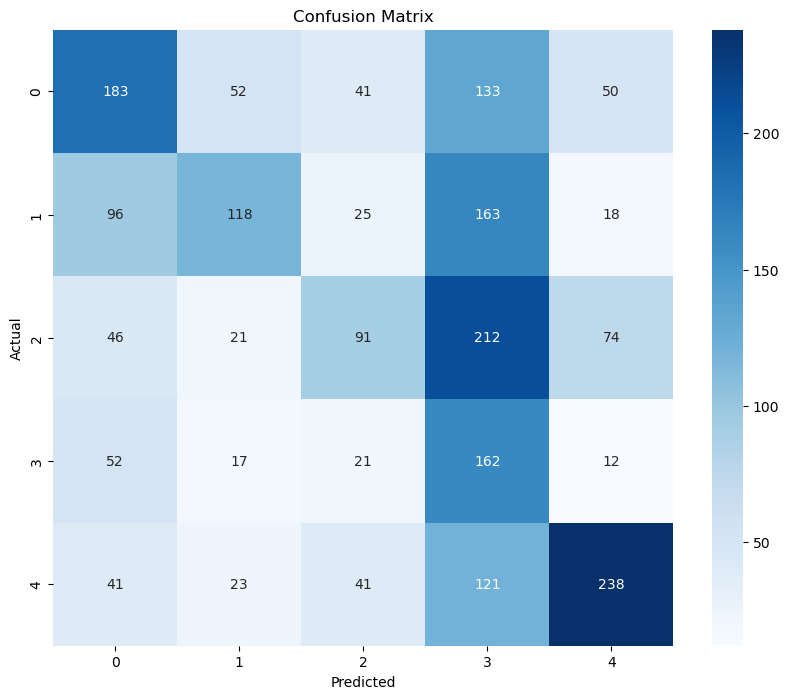

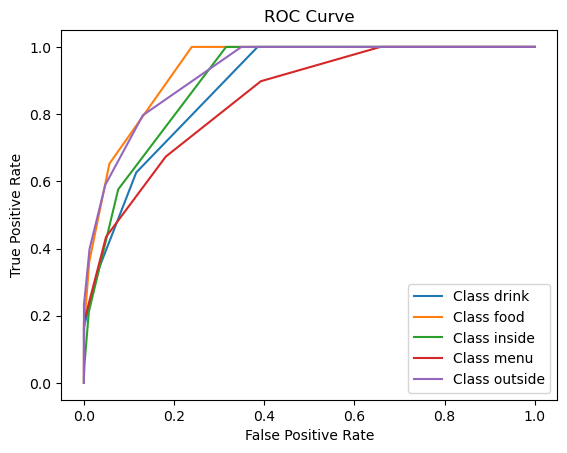

In [88]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC Curve (One-vs-Rest)
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_train == i, y_train_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]}")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

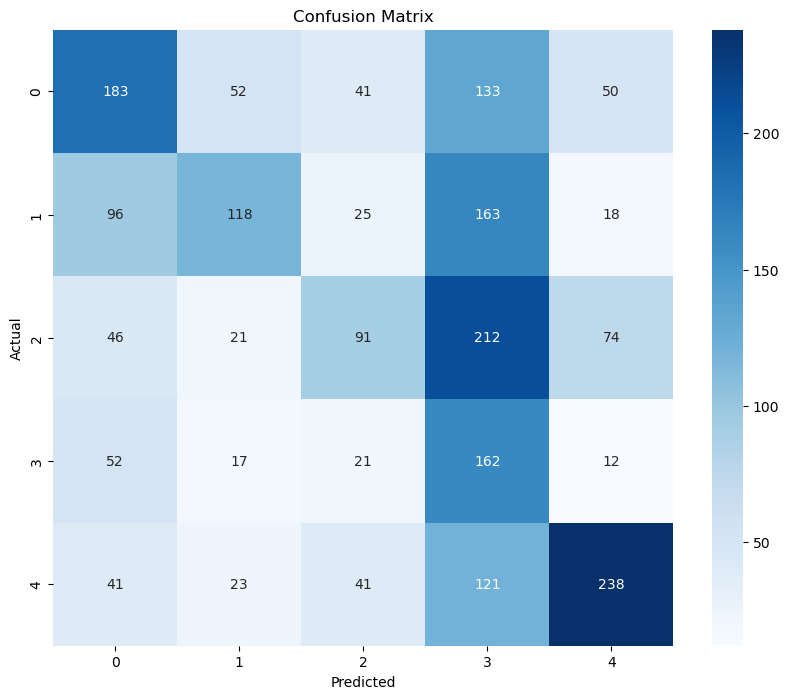

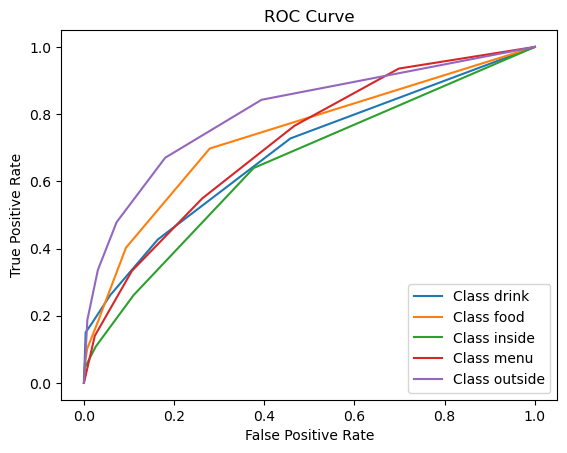

In [89]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC Curve (One-vs-Rest)
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_val == i, y_val_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]}")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

<b> There's somewhat improvement but very few happening. Even so there is less overfitting than the first model

### Global Interpretation

Nearest Neighbors' Labels: [3 4 3 1 0]


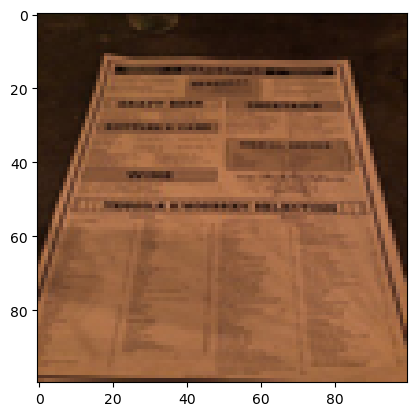

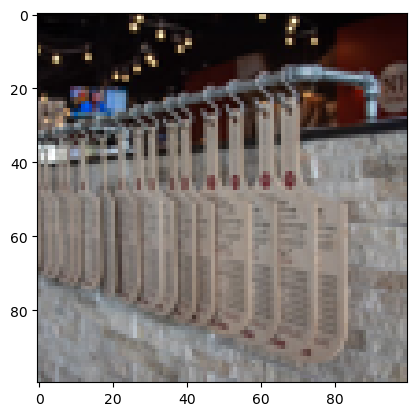

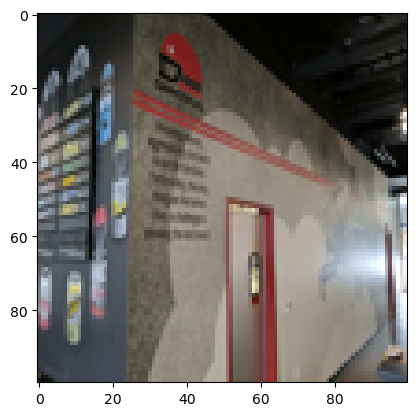

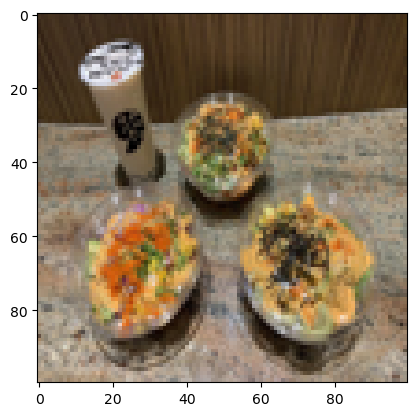

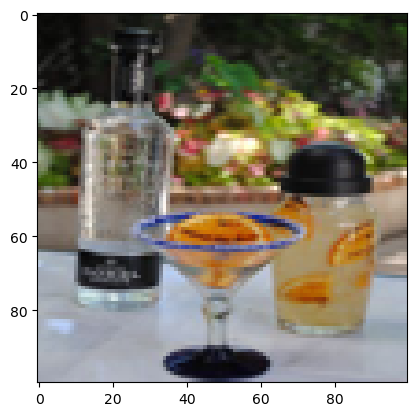

In [92]:
def visualize_nearest_neighbors(knn, instance, X_train, y_train):
    distances, indices = knn.kneighbors(instance.reshape(1, -1))
    print("Nearest Neighbors' Labels:", y_train[indices.flatten()])

    for idx in indices.flatten():
        plt.imshow(X_train[idx].reshape(100, 100, 3).astype("uint8"))
        plt.show()

visualize_nearest_neighbors(knn, X_test_flat[0], X_train, y_train)

In [122]:
def predict_proba_for_lime(images):
    """Flatten all images, apply scaling, and return predicted probabilities from kNN."""
    flattened_images = np.array([img.flatten() for img in images])  # Flatten images
    scaled_images = scaler.transform(flattened_images)  # Apply scaling
    return knn.predict_proba(scaled_images)

  0%|          | 0/1000 [00:00<?, ?it/s]

Top labels explained: [3, 4, 1, 0, 2]


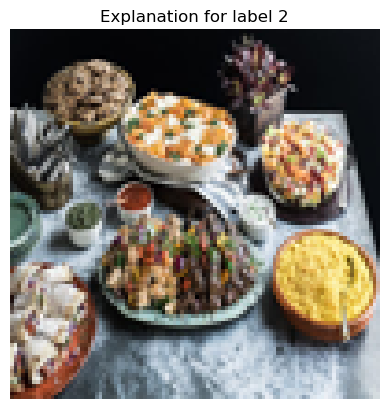

Predicted probabilities: [[0.2 0.4 0.  0.4 0. ]]
True label probability: 0.0


In [124]:
# Example LIME explanation
explainer = lime_image.LimeImageExplainer()

# Explain the first test image
explanation = explainer.explain_instance(
    X_test[0],  # The test image
    predict_proba_for_lime,  # Wrapped prediction function
    labels=[y_test[0]],  # Force LIME to explain the true label
    hide_color=0,
    num_samples=1000
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Visualize the explanation for the true label
temp, mask = explanation.get_image_and_mask(
    label=y_test[0],  # The true label
    positive_only=True,  # Show only positive contributions
    num_features=10,  # Number of features to display
    hide_rest=False  # Show the rest of the image
)

# Convert `temp` to ensure it is in the correct format for visualization
if len(temp.shape) == 2:  # If grayscale, convert to RGB
    temp = gray2rgb(temp)

# Overlay the mask on the image
overlay = mark_boundaries(temp, mask)

# Plot the image with the explanation
plt.imshow(overlay)
plt.title(f"Explanation for label {y_test[0]}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = knn.predict_proba(preprocess_image(X_test[0]))
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, y_test[0]]}")

In [125]:
class_names = label_encoder.classes_
print("Class names:", class_names)

Class names: ['drink' 'food' 'inside' 'menu' 'outside']


<b> No boundaries and randomly guessed inside even with better resolution and standardization

  0%|          | 0/1000 [00:00<?, ?it/s]

Top labels explained: [4, 3, 2, 1, 0]


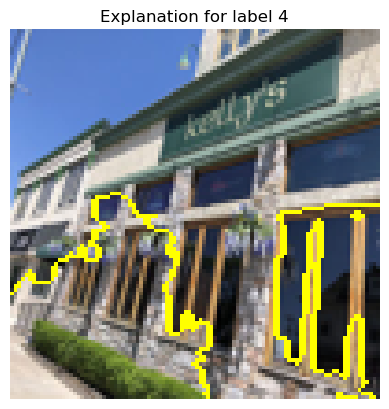

Predicted probabilities: [[0.4 0.4 0.  0.2 0. ]]
True label probability: 0.0


In [127]:
# Example LIME explanation
explainer = lime_image.LimeImageExplainer()

# Explain the first test image
explanation = explainer.explain_instance(
    X_test[1],  # The test image
    predict_proba_for_lime,  # Wrapped prediction function
    labels=[y_test[1]],  # Force LIME to explain the true label
    hide_color=0,
    num_samples=1000
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Visualize the explanation for the true label
temp, mask = explanation.get_image_and_mask(
    label=y_test[1],  # The true label
    positive_only=True,  # Show only positive contributions
    num_features=10,  # Number of features to display
    hide_rest=False  # Show the rest of the image
)

# Convert `temp` to ensure it is in the correct format for visualization
if len(temp.shape) == 2:  # If grayscale, convert to RGB
    temp = gray2rgb(temp)

# Overlay the mask on the image
overlay = mark_boundaries(temp, mask)

# Plot the image with the explanation
plt.imshow(overlay)
plt.title(f"Explanation for label {y_test[1]}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = knn.predict_proba(preprocess_image(X_test[1]))
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, y_test[1]]}")

<b> Here more information comes into play that may have helped it to predict such as the windows and the walls.

# Let's move to SVM now, there won't be tuning/Interpretability per the nature of SVM, takes too long to run. But we will try to be fair against KNN and run it standardized.

In [39]:
# Load the dataset
X, missing_ids = load_and_preprocess_images(balanced_df["photo_id"], "data/balanced_photos", IMAGE_SIZE= (64,64))
y = balanced_df[~balanced_df["photo_id"].isin(missing_ids)]["label"]

Error loading image 2S78q98b_VpBD7vkrDE5-A: cannot identify image file 'C:\\Users\\leand\\GitHub\\AISC-T3-Grp2\\AISC2008 - Computer Vision\\Case Study 1\\Leandro\\data\\balanced_photos\\2S78q98b_VpBD7vkrDE5-A.jpg'
Error loading image rLafN9k3_AF5lZU0cs3LZg: cannot identify image file 'C:\\Users\\leand\\GitHub\\AISC-T3-Grp2\\AISC2008 - Computer Vision\\Case Study 1\\Leandro\\data\\balanced_photos\\rLafN9k3_AF5lZU0cs3LZg.jpg'
Missing or problematic images: 2


In [40]:
X.shape

(13676, 64, 64, 3)

In [41]:
y.shape

(13676,)

In [42]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

### Split into train test and val

In [44]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Let's start with the KNN method now.

First let's flatten it to run.

In [47]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [48]:
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_val_flat = scaler.transform(X_val_flat)
X_test_flat = scaler.transform(X_test_flat)

In [50]:
# Initialize the kNN model
svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)

# Train the model
svc.fit(X_train_flat, y_train)

SVC(probability=True)

Trained from 9h30PM 28th of jan to 7AM 29th of jan

In [51]:
# Predict on train data
y_train_pred = svc.predict(X_train_flat)
y_train_probs = svc.predict_proba(X_train_flat)

In [52]:
# Same for test
y_test_pred = svc.predict(X_test_flat)
y_test_probs = svc.predict_proba(X_test_flat)

In [53]:
# Same for val
y_val_pred = svc.predict(X_val_flat)
y_val_probs = svc.predict_proba(X_val_flat)

In [54]:
# Evaluate
cm = confusion_matrix(y_train, y_train_pred)
auc = roc_auc_score(y_train, y_train_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Confusion Matrix:
 [[1541  112  284   46   96]
 [  92 1837  104   32   54]
 [  58   55 1899   30   92]
 [  49   70  242  719   47]
 [  69   40  282   15 1708]]
AUC Score: 0.9644839677757059
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.50      0.55       462
           1       0.67      0.71      0.69       459
           2       0.49      0.70      0.58       422
           3       0.71      0.47      0.57       287
           4       0.69      0.65      0.67       422

    accuracy                           0.62      2052
   macro avg       0.64      0.61      0.61      2052
weighted avg       0.63      0.62      0.62      2052



In [55]:
# Evaluate
cm = confusion_matrix(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Confusion Matrix:
 [[229  80  93  20  40]
 [ 59 328  43  19  10]
 [ 31  35 297   9  50]
 [ 19  27  82 135  24]
 [ 27  18  95   6 276]]
AUC Score: 0.8677174361832737
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.50      0.55       462
           1       0.67      0.71      0.69       459
           2       0.49      0.70      0.58       422
           3       0.71      0.47      0.57       287
           4       0.69      0.65      0.67       422

    accuracy                           0.62      2052
   macro avg       0.64      0.61      0.61      2052
weighted avg       0.63      0.62      0.62      2052



In [56]:
# Evaluate
cm = confusion_matrix(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_val, y_val_pred))

Confusion Matrix:
 [[208  82  99  17  53]
 [ 57 304  42   4  13]
 [ 32  22 330   9  51]
 [ 23  27  70 128  16]
 [ 16  16 107   5 320]]
AUC Score: 0.8703313554282743
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.45      0.52       459
           1       0.67      0.72      0.70       420
           2       0.51      0.74      0.60       444
           3       0.79      0.48      0.60       264
           4       0.71      0.69      0.70       464

    accuracy                           0.63      2051
   macro avg       0.66      0.62      0.62      2051
weighted avg       0.65      0.63      0.63      2051



### Right from here we see much better results than KNN. I wonder what LIME will see, I will try to leave it running with lime. Let's hope it doesn't take too long

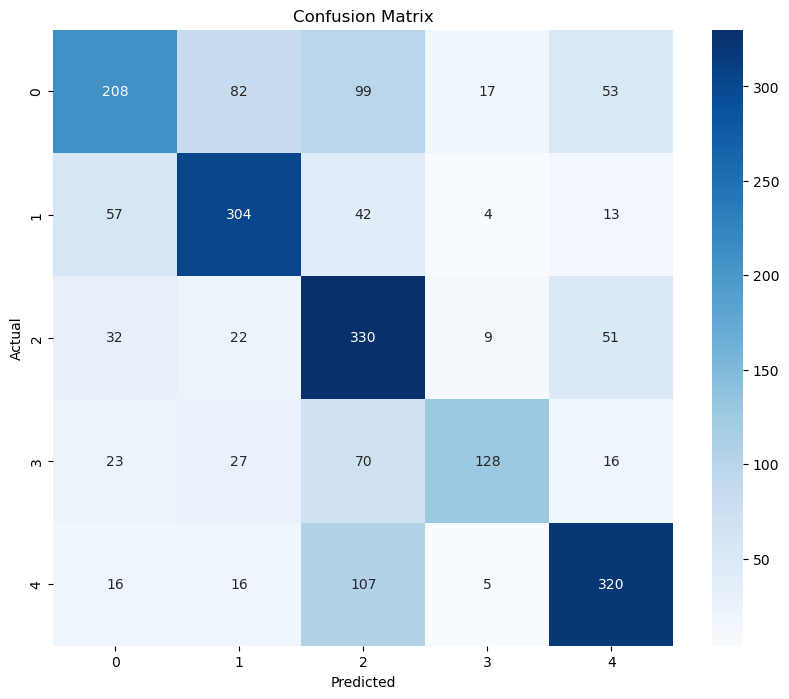

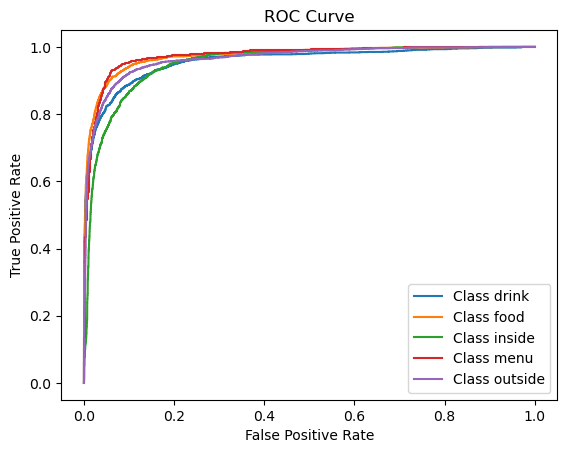

In [57]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC Curve (One-vs-Rest)
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_train == i, y_train_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]}")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

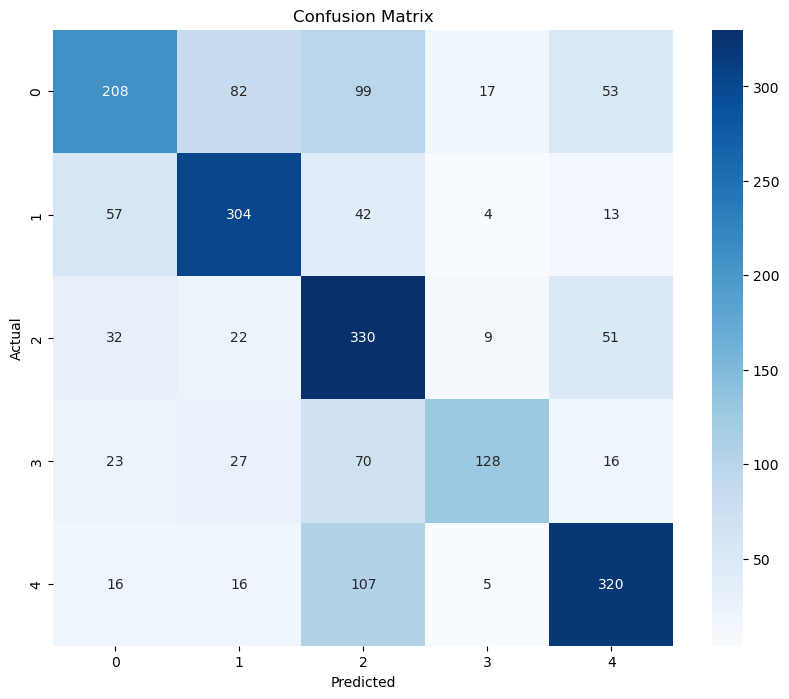

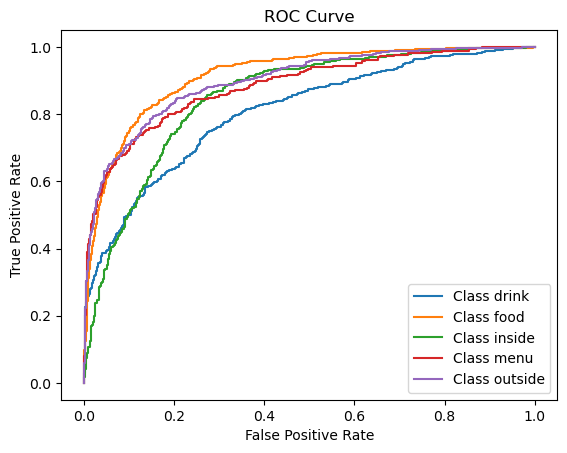

In [58]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC Curve (One-vs-Rest)
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_val == i, y_val_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]}")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Even the AUC ia way better, but shows some overfitting.

In [72]:
def predict_proba_for_lime(images):
    """Flatten all images, apply scaling, and return predicted probabilities from kNN."""
    flattened_images = np.array([img.flatten() for img in images])  # Flatten images
    scaled_images = scaler.transform(flattened_images)  # Apply scaling
    return svc.predict_proba(scaled_images)

  0%|          | 0/1000 [00:00<?, ?it/s]

Top labels explained: [1, 0, 4, 2, 3]


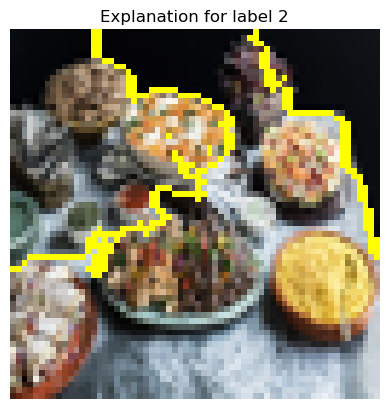

Predicted probabilities: [[0.34939449 0.44795284 0.08326217 0.01343246 0.10595805]]
True label probability: 0.08326216739157999


In [82]:
# Example LIME explanation
explainer = lime_image.LimeImageExplainer()

# Explain the first test image
explanation = explainer.explain_instance(
    X_test[0],  # The test image
    predict_proba_for_lime,  # Wrapped prediction function
    labels=[y_test[0]],  # Force LIME to explain the true label
    hide_color=0,
    num_samples=1000
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Visualize the explanation for the true label
temp, mask = explanation.get_image_and_mask(
    label=y_test[0],  # The true label
    positive_only=True,  # Show only positive contributions
    num_features=10,  # Number of features to display
    hide_rest=False  # Show the rest of the image
)

# Convert `temp` to ensure it is in the correct format for visualization
if len(temp.shape) == 2:  # If grayscale, convert to RGB
    temp = gray2rgb(temp)

# Overlay the mask on the image
overlay = mark_boundaries(temp, mask)

# Plot the image with the explanation
plt.imshow(overlay)
plt.title(f"Explanation for label {y_test[0]}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = svc.predict_proba(preprocess_image(X_test[0]))
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, y_test[0]]}")

In [83]:
class_names = label_encoder.classes_
print("Class names:", class_names)

Class names: ['drink' 'food' 'inside' 'menu' 'outside']


<b> We can see it paying attention to the foods on the table but also to the environment around, so it guessed wrong

  0%|          | 0/1000 [00:00<?, ?it/s]

Top labels explained: [4, 0, 2, 1, 3]


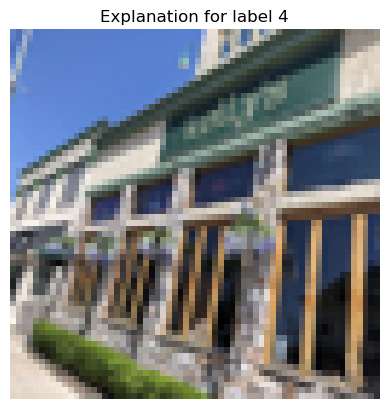

Predicted probabilities: [[0.34939449 0.44795284 0.08326217 0.01343246 0.10595805]]
True label probability: 0.10595804734247148


In [85]:
# Example LIME explanation
explainer = lime_image.LimeImageExplainer()

# Explain the first test image
explanation = explainer.explain_instance(
    X_test[1],  # The test image
    predict_proba_for_lime,  # Wrapped prediction function
    labels=[y_test[1]],  # Force LIME to explain the true label
    hide_color=0,
    num_samples=1000
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Visualize the explanation for the true label
temp, mask = explanation.get_image_and_mask(
    label=y_test[1],  # The true label
    positive_only=True,  # Show only positive contributions
    num_features=10,  # Number of features to display
    hide_rest=False  # Show the rest of the image
)

# Convert `temp` to ensure it is in the correct format for visualization
if len(temp.shape) == 2:  # If grayscale, convert to RGB
    temp = gray2rgb(temp)

# Overlay the mask on the image
overlay = mark_boundaries(temp, mask)

# Plot the image with the explanation
plt.imshow(overlay)
plt.title(f"Explanation for label {y_test[1]}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = svc.predict_proba(preprocess_image(X_test[1]))
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, y_test[1]]}")

<b> We can't really see the attention, but it correctly guessed outside

## Now we will be moving to DNN/CNN Models. The other empirical tunings will be made on this models